# Simple Linear Regression

Linear regression assumes a linear or straight line relationship between the input variables (X) and the single output variable (y). More specically, a linear regression model allows us to calculate (i.e. predict or estimate) the output (y) from a
linear combination of the input variables (X). When there is a single input variable, the method
is referred to as a simple linear regression.

Simple linear regression produces a model in the form:

ŷ = α + Bx

- ŷ - response variable (a.k.a the output variable a.k.a the value we are trying to predict)
- α - intercept
- B - regression coefficient
- x - predictor variable (a.k.a input variable)


In [36]:
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt

%matplotlib inline

In [37]:
df = pd.read_csv("../data/nhl_season_goals.csv")
df.head()

,rank,position,hand,player,years,total_goals,status,yr_start,season,age,...,goals,assists,points,plus_minus,penalty_min,goals_even,goals_power_play,goals_short_handed,goals_game_winner,headshot
0,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1978-79,18,...,46,64,110,20.0,19,NaN,NaN,NaN,NaN,https://d9kjk42l7bfqz.cloudfront.net/req/20191...
1,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1978-79,18,...,3,3,6,-3.0,0,3.0,0.0,0.0,NaN,https://d9kjk42l7bfqz.cloudfront.net/req/20191...
2,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1978-79,18,...,43,61,104,23.0,19,34.0,9.0,0.0,NaN,https://d9kjk42l7bfqz.cloudfront.net/req/20191...
3,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1979-80,19,...,51,86,137,14.0,21,37.0,13.0,1.0,6.0,https://d9kjk42l7bfqz.cloudfront.net/req/20191...
4,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1980-81,20,...,55,109,164,41.0,28,36.0,15.0,4.0,3.0,https://d9kjk42l7bfqz.cloudfront.net/req/20191...


In [38]:
df.dropna(inplace=True)

<Axes: xlabel='assists', ylabel='points'>

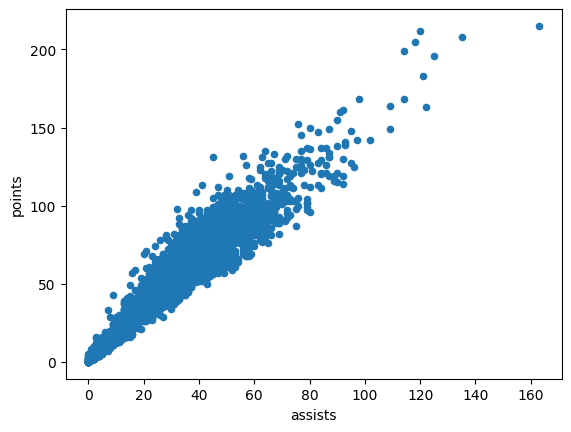

In [39]:
# Let's plot the data and see if there are any interesting patterns
# that we can observe in the relationship between 'high' and 'close'
df.plot.scatter(x="assists", y="points")

In [40]:
df.sample(5)[["assists", "points"]]

,assists,points
20,66,81
2053,75,87
1840,16,33
312,29,57
418,11,17


## Simple Linear Regression With "Pen and Paper"

As mentioned above, we need to derive the following formula from the data:

ŷ = α + Bx

In order to derive this formula, we need to take the following steps:

1. Calculate the mean of the X variable.
2. Calculate the difference between each X and the mean X.
3. Square the differences and add it all up and divide by the number of values in your data column / list. This is SSxx (variance of x).
4. Calculate the mean of the Y variable.
5. Calculate the variance of the Y variable.
6. Multiply the differences (of X and Y from their respective means), add them all together This is SSxy (covariance of y and x).
7. Using SSxx and SSxy, you calculate the intercept by subtracting SSxx / SSxy \* AVG(X) from AVG(Y).


**The Data**
Let's take a small subset of our stocks data, something that we can easily do calculations on by hand

| Assists (x) | Points (y) |
| ----------- | ---------- |
| 48          | 89         |
| 56          | 84         |
| 45          | 70         |
| 25          | 43         |
| 33          | 63         |

**Step 1: Calculate the mean of our X variable.**
mean(X) = (48 + 56 + 45 + 25 + 33) / 5 = 41.4

\*\*Step 2: Calculate the difference between each X and the mean X and each Y and the mean Y.

| x   | mean(x) - x | Difference between <br /> each X and the mean X | mean(y) - y | difference between <br /> each Y and the mean Y |
| --- | ----------- | ----------------------------------------------- | ----------- | ----------------------------------------------- |
| 48  | (41.4 - 48) | -6.4                                            | (69.8 - 89) | -19.2                                           |
| 56  | (41.4 - 56) | -14.6                                           | (69.8 - 84) | -14.2                                           |
| 45  | (41.4 - 45) | -3.6                                            | (69.8 - 70) | -0.2                                            |
| 25  | (41.4 - 25) | 16.4                                            | (69.8 - 43) | 26.8                                            |
| 33  | (41.4 - 33) | 8.4                                             | (69.8 - 63) | 6.8                                             |

**Step 3: Calculate the variance of X (SSxx)**

$variance = \sum_{i=1}^{n}(x_{\text{i}} - mean(x))^2$

SSxx = (-6.4)<sup>2</sup> + (-14.6)<sup>2</sup> + (-3.6)<sup>2</sup> + (16.4)<sup>2</sup> + (8.4)<sup>2</sup> = 606.6

**Step 4: Calculate mean of the Y variable.**

mean(Y) = (89 + 84 + 70 + 43 + 63) / 5 = 69.8

**Step 5: Calculate the variance of the Y variable (SSyy)**

SSyy = (-19.2)<sup>2</sup> + (-14.2)<sup>2</sup> + (-0.2)<sup>2</sup> + (26.8)<sup>2</sup> + (6.8)<sup>2</sup> = 1334.8

**Step 6: Calculate the covariance of X and Y (SSxy)**

$covariance = \sum_{i=1}^{n}((x_{\text{i}}-mean(x)) * (y_{\text{i}}-mean(y)))$

SSxy = (mean(X)-X) _ (mean(Y)-Y) = (-6.4 * -19.2) + (-14.6 * -14.2) + (-3.6 * -0.2) + (16.4 * 26.8) + (8.4 * 6.8) = 827.56

**Step 7: Calculate the slope of the line**

$slope = \frac{covariance(x, y)}{variance(x)}$

a = SSxy / SSxx = 827.56 / 606.6 = 1.365

**Step 8: Calculate the intercept**

$intercept = \beta_{0}$ = mean(y) - slope \* mean(x)$

b = mean(Y) – slope _ mean(X) = 69.8 - (1.364 * 41.4) = 13.300

**Our model**

ŷ = 13.300 + 1.365x


## Machine Learning with Python 'By Hand'

### In other words, we will come up with a linear regression function without the use of any machine learning libraries - we will write our own!


### Split our data into training and testing subsets


In [41]:
def test_train_split(x, y, test_sample_size=0.2):
    # Initialize resulting lists
    x_train, y_train, x_test, y_test = [], [], [], []

    # Create a list of indexes from the original list of values
    idx = list(range(0, len(x)))

    # Calculate how many values from the list actully constitute the
    # test_sample_size

    num_of_values_in_test = math.floor(len(idx) * test_sample_size)

    # Randomly select a percentage of values for train / test
    test_idx = random.sample(idx, num_of_values_in_test)

    for i in idx:
        if i in test_idx:
            x_test.append(x[i])
            y_test.append(y[i])
        else:
            x_train.append(x[i])
            y_train.append(y[i])

    return x_train, y_train, x_test, y_test

In [42]:
x = list(df["assists"])
y = list(df["points"])

x_train, y_train, x_test, y_test = test_train_split(x, y)

### Build our regressor

In [43]:
def multiply(a: float, b: float) -> float:
   return a*b

def simple_linear_regression(X: list, y: list) -> tuple[float, float]:
   #CHECK IF X and y ARE COMPATIBLE (Length, Type)
#    input_check(X, y)
  
   n = len(X)
   sum_X, sum_y = sum(X), sum(y)
   sum_X2 = sum([x**2 for x in X])
   sum_Xy = sum(list(map(multiply, X, y)))

   coef_ = (n * sum_Xy - sum_X * sum_y) / (n * sum_X2 - sum_X * sum_X)
   intercept_ = (sum_y - coef_ * sum_X) / n

   return (coef_, intercept_)

In [44]:
# regressor with normal equation
def OLS_normal_equation(X: np.array, y: np.array) -> np.array:
    # Add a column of ones to X for the intercept term
    X_with_intercept = np.append(np.ones((X.shape[0],1)), X, axis=1)

    X_t = np.transpose(X_with_intercept)
    X_t_X = np.dot(X_t, X_with_intercept)
    X_t_y = np.dot(X_t, y)

    try:
        theta = np.linalg.solve(X_t_X, X_t_y)
        return theta
    except np.linalg.LinAlgError:
        return None

### Make predictions / estimations


In [45]:
def predict_with_simple_linear_regression(a_coeff, b_coeff, x_test):
    predictions = list()

    # Test our model by generating predictions
    for val in x_test:
        # print(row)
        yhat = a_coeff + b_coeff * val
        predictions.append(yhat)
    return predictions

In [54]:
# Train our model - calculate coefficients based
# on the training dataset
slope, intercept = simple_linear_regression(x_train, y_train)

print(slope, intercept)

pred = predict_with_simple_linear_regression(intercept, slope, x_test)

df_result = pd.DataFrame({'x_test': x_test, 'y_actual': y_test, 'y_predict': pred})
df_result.head(10)

1.4930548027511221 7.199274947501038


,x_test,y_actual,y_predict
0,114,168,177.407522
1,13,21,26.608987
2,49,72,80.358960
3,44,77,72.893686
4,43,82,71.400631
5,70,102,111.713111
6,37,69,62.442303
7,60,94,96.782563
8,67,99,107.233947
9,29,45,50.497864


### Evaluate the model with RMSE


In [52]:
# Calculate root mean squared error
def rmse_metric(actual, predicted):
    sum_error = 0.0
    for i in range(len(actual)):
        prediction_error = predicted[i] - actual[i]
        sum_error += prediction_error**2
        mean_error = sum_error / float(len(actual))
    return math.sqrt(mean_error)

In [53]:
rmse = rmse_metric(y_test, pred)
print(rmse)

9.864090231860908


## Simple Linear Regression with scikit-learn

The linear regression algorithm accomplishes this by deriving a line formula that minimizes the differences between actual values and predicted values. This algorithm is called **ordinary least-squares**, or **OLS**.

**Scikit-learn** Python module provides a LinearRegression function for doing this job.


In [30]:
# In this example, we will try to estimate the value of Apple stock at stock market closing
# using the value of it's highest cost during a given day.  In other words, we will try
# to predict the value of 'close' using the value of 'high'
# To put this in machine learning / data mining terms, 'close' is our response variable and
# 'high' our predictor variable
X = df[["assists"]]
y = df[["points"]]

In [31]:
# Split Data
# Now we can split our data into a training and test set.  In this example, we are using an 80/20 split,
# where 80% of our data will be used for training our model, and 20% of our data will be used for testing.

from sklearn.model_selection import train_test_split

# Split X and y into X_
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1
)

In [32]:
# Train Model
# Now we train our LinearRegression model using the training subset of data.

from sklearn.linear_model import LinearRegression

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# Now that our model is trained, we can view the coefficients of the model using regression_model.coef_,
# which is an array of tuples of coefficients.
# Each regression coefficient shows the strength of the relationship between the predictor variable and the
# outcome variable while controlling for the other predictor variable

for idx, col_name in enumerate(X_train.columns):
    print(
        "The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx])
    )

The coefficient for assists is 1.504661021160344


In [34]:
# regression_model.intercept_ returns an array of intercepts
intercept = regression_model.intercept_[0]

print("The intercept for our model is {}".format(intercept))

The intercept for our model is 6.870548823655476


Now that we know the regression coefficient for our predictor variable and the intercept, we can figure out our model.

You might also notice the slope and intercept here are slightly different from the earlier
number when we built the model our self. This is due to the randomness in the traning and
testing data split process. We are getting probably different splits of the training and
testing data in both examples.


In [ ]:
regression_model.predict([[20]])

## How good is our model

### the $R^{2}$ statistic

A common method of measuring the accuracy of regression models is to use the $R^{2}$ statistic.

The $R^{2}$ statistic is defined as follows:

$R^{2}$ = 1 – (RSS/TSS)

- The RSS (Residual sum of squares) measures the variability left unexplained after performing the regression
- The TSS measues the total variance in Y
- Therefore the $R^{2}$ statistic measures proportion of variability in Y that is explained by X using our model

The scale of $R^{2}$ statistic ranges from zero to one, with zero indicating that the proposed model **does not improve prediction over the mean model and one indicating perfect prediction**. Improvement in the regression model results in proportional increases in R-squared.


In [36]:
# R^2  can be determined using our test set and the model’s score method.

regression_model.score(X_test, y_test)

# This means that in our model, 93.3% of the variability in Y can be explained using X

0.8852594032661038

### Adjusted $R^{2}$ Score

To calculate the adjusted $R^{2}$ score for your regression model, we can use the following formula:

$R_{\text{adj}}^2 = 1 - (1 - R^2) \frac{n-1}{n-p-1}$

Where n is the sample size, and p is the total number of predictors in the model. It is derived from the definition of adjusted $R^{2}$:

$R_{\text{adj}}^2 = 1 - \frac{SS_{\text{res}} / df_{\text{res}}}{SS_{\text{tot}} / df_{\text{tot}}}$

where $df_{\text{res}}$ is the degrees of freedom of the estimate of the population variance around the model, and $df_{\text{tot}}$ is the degrees of freedom of the estimate of the population variance around the mean.


In [38]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, regression_model.predict(X_test))
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print(f"R^2: {r2:.4f}, Adjusted R^2: {adjusted_r2:.4f}")

R^2: 0.8853, Adjusted R^2: 0.8851


### RMSE


In [39]:
# If you are using scikit-learn version 1.4+, you can calculate RMSE using the
# `root_mean_squared_error` function from `sklearn.metrics` submodule
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, regression_model.predict(X_test))
print("RMSE: %.3f" % (rmse))

RMSE: 10.408


In [ ]:
# If you are using an earlier version (<1.4) of scikit-learn, you can use
# `mean_squared_error` funcion to calculate MSE and taking the square root of the result
# to get RMSE
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, regression_model.predict(X_test))
print(f"RMSE: {math.sqrt(mse):.3f}")

## Gradient descent example

In [97]:
# X, y should be an 2D np.array representation of the matrix format
# shape should be (length of the data, number of features)
def ols_gradient_descent(X, y, learning_rate = 0.01, n_iteration = 100, random_state = None):
    if random_state:
        random.seed(10)

    size = X.shape[0]
    X_m = np.c_[np.ones((size, 1)), X] # adding one column of 1 in front to include the intercept, case
    starting_state = np.array(random.sample(range(1, 100), X.shape[1] + 1))
    print(starting_state)
    theta = starting_state.reshape(-1, 1)

    for _ in range(n_iteration):
        pred = X_m.dot(theta)
        gradients = (2 / size) * X_m.T.dot(pred - y)
        theta = theta - learning_rate * gradients
    
    return theta.reshape(-1, 1)

ols_gradient_descent(X, y, learning_rate=0.0005, n_iteration=100000, random_state=42)

[74  5]


array([[13.37942452],
       [ 1.36294352]])

### Scikit learn also has dedicated regressors using gradient descent. 

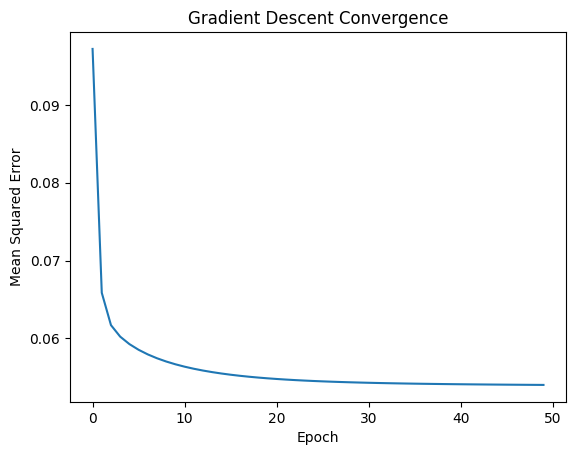

In [89]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import mean_squared_error

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True, learning_rate='invscaling', eta0=0.01, random_state=42)
n_epochs = 50
mse_list = []

for epoch in range(n_epochs):
    sgd_reg.fit(X_train_scaled, y_train)
    y_pred = sgd_reg.predict(X_train_scaled)
    mse = mean_squared_error(y_train, y_pred)
    mse_list.append(mse)

plt.plot(np.arange(n_epochs), mse_list)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Gradient Descent Convergence')
plt.show()